**This is one of the most common RNN interview and industry projects.**

# **Problem Statement**

Imagine you own an online movie platform.

Every day, thousands of users write reviews.

Example:

```
Movie 1:
"This movie was absolutely amazing."
```

```
Movie 2:
"I wasted my money. Very boring movie."
```

Reading thousands of reviews manually is impossible.

We want AI to automatically predict:

- 😊 Positive Review
- 😞 Negative Review

# **Why RNN?**

Sentence order matters.

Example

Review 1

```
This movie is good.

Positive ✅
```

Review 2

```
This movie is not good.

Negative ❌
```

The only difference is

```
not
```

If the model forgets previous words,

it will wrongly predict Positive.

RNN remembers previous words.

## **Complete Workflow**

```
Movie Reviews
↓
Load Dataset
↓
EDA
↓
Text Cleaning
↓
Tokenization
↓
Padding
↓
Train-Test Split
↓
Embedding Layer
↓
Simple RNN
↓
Dense Layer
↓
Prediction
↓
Evaluation
↓
Accuracy Graph
↓
Loss Graph
↓
Test New Review
```

# **Step 1**
**Import Libraries**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb # Interne Movie Dataset

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

# **Step 2**
**Load IMDb Dataset**

TensorFlow already provides this dataset.

In [ ]:
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# **Step 3**
**Explore Dataset**

In [ ]:
print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 25000
Testing Samples : 25000


# **Step 4**
**Check One Review**

In [ ]:
print(X_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


# **Step 5**
**Convert Review Back to Text**

In [ ]:
word_index = imdb.get_word_index()

reverse_word_index = {value:key for key, value in word_index.items()}

decoded_review = " ".join(
    reverse_word_index.get(i-3, "?")
    for i in X_train[0]
)

print(decoded_review)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should

# **Step 6**
**Padding**

Reviews have different lengths.

Make every review length = 200.

In [ ]:
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

# **Step 7**
**Build RNN Model**

In [ ]:
model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

model.add(
    SimpleRNN(64)
)

model.add(Dropout(0.5))

model.add(
    Dense(1, activation="sigmoid")
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# **Step 8**
**Compile Model**

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# **Step 9**
**Model Summary**

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **Step 10**
**Train Model**

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7016 - loss: 0.5504 - val_accuracy: 0.8028 - val_loss: 0.4373
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8633 - loss: 0.3423 - val_accuracy: 0.8058 - val_loss: 0.4357
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9217 - loss: 0.2118 - val_accuracy: 0.8028 - val_loss: 0.4474
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9646 - loss: 0.1092 - val_accuracy: 0.8208 - val_loss: 0.5052
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9816 - loss: 0.0590 - val_accuracy: 0.8272 - val_loss: 0.5435
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9928 - loss: 0.0260 - val_accuracy: 0.8384 - val_loss: 0.6153
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9983 - loss: 0.0084 - val_accuracy: 0.8432 - val_loss: 0.6816
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9863 - loss: 0.0390 - val_acc

# **Step 11**
**Evaluate Model**

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8137 - loss: 0.7913
Loss : 0.7912599444389343
Accuracy : 0.8137199878692627


# **Step 12**
**Accuracy Graph**

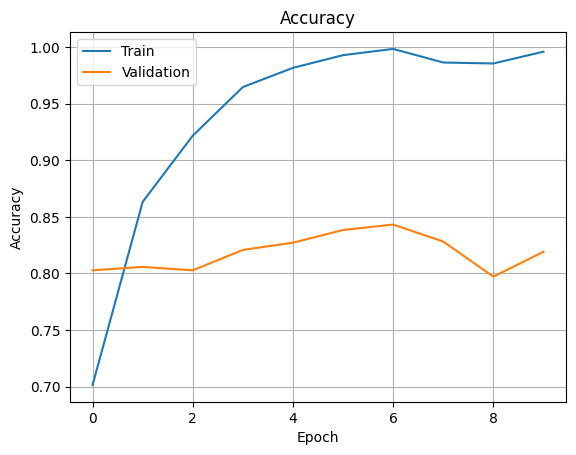

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])
plt.grid()

plt.show()

# **Step 13**
**Loss Graph**

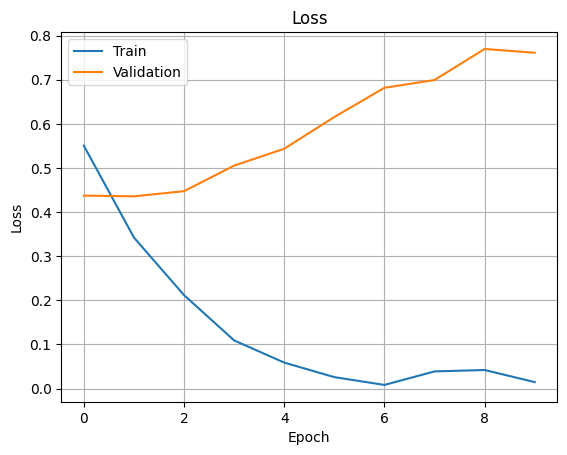

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])
plt.grid()

plt.show()

# **Step 14**
**Test Your Own Review**

In [ ]:
sample_review = "This movie was fantastic and full of action"

# **RNN Architecture**

```
Movie Review
↓
Tokenizer
↓
Word IDs
↓
Padding
↓
Embedding Layer
↓
Simple RNN (64 Units)
↓
Dropout
↓
Dense Layer (Sigmoid)
↓
Positive / Negative
```

# **How RNN Thinks**

Review:

```
This movie was absolutely fantastic
```

The RNN processes one word at a time:

```
"This"
     ↓
Hidden State h1

"movie"
     ↓
Uses h1
     ↓
Hidden State h2

"was"
     ↓
Uses h2
     ↓
Hidden State h3

"absolutely"
     ↓
Uses h3
     ↓
Hidden State h4

"fantastic"
     ↓
Uses h4
     ↓
Positive Review
```

Each hidden state carries information from the previous words, allowing the model to understand the sentence progressively.